In [53]:
import pandas as pd;
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [54]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [55]:
import matplotlib.pyplot as plt

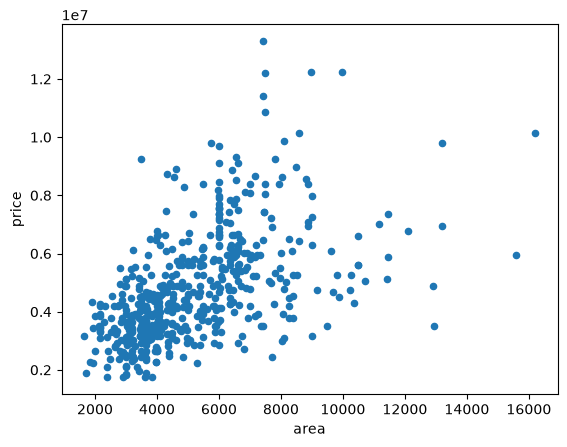

In [56]:
df.plot(kind="scatter",x='area',y='price')
plt.show()

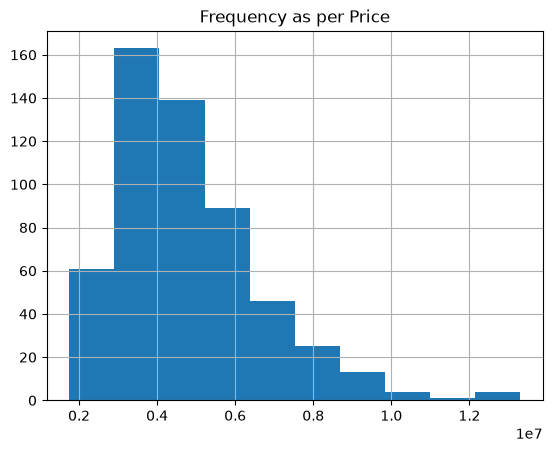

In [57]:
df['price'].hist()
plt.title('Frequency as per Price')
plt.show()

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [59]:
#Declaring Numerical and Categorical Data
cat_columns = df.select_dtypes('str').columns
num_columns = df.select_dtypes('int64').columns
print(cat_columns)
df[cat_columns].apply(lambda x:x.value_counts())


Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')


,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
furnished,NaN,NaN,NaN,NaN,NaN,NaN,140.0
no,77.0,448.0,354.0,520.0,373.0,417.0,NaN
semi-furnished,NaN,NaN,NaN,NaN,NaN,NaN,227.0
unfurnished,NaN,NaN,NaN,NaN,NaN,NaN,178.0
yes,468.0,97.0,191.0,25.0,172.0,128.0,NaN


In [60]:
print(df['mainroad'].value_counts())
df['mainroad']= df['mainroad'].map({
    "yes":1,
    "no":0
})
print(df['mainroad'].value_counts())

mainroad
yes    468
no      77
Name: count, dtype: int64
mainroad
1    468
0     77
Name: count, dtype: int64


In [61]:
# Fix Bolean vlaues into 0 amd 1
cols =['guestroom','basement','hotwaterheating','airconditioning','prefarea']
df[cols]=df[cols].apply(lambda x:x.map({"yes":1,"no":0}))

In [62]:
df[cat_columns]

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,1,0,0,0,1,1,furnished
1,1,0,0,0,1,0,furnished
2,1,0,1,0,0,1,semi-furnished
3,1,0,1,0,1,1,furnished
4,1,1,1,0,1,0,furnished
...,...,...,...,...,...,...,...
540,1,0,1,0,0,0,unfurnished
541,0,0,0,0,0,0,semi-furnished
542,1,0,0,0,0,0,unfurnished
543,0,0,0,0,0,0,furnished


In [63]:
# Fixing Categorical column of Furnished
encoded_df = pd.get_dummies(df,'furnishingstatus',drop_first=True)
encoded_df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,False,True
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,True,False
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,False,True
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,False,False


Detect outliers using the IQR method

In [64]:
df['price'].describe()

count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64

In [65]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IRQ = Q3-Q1
lower_bound = Q1-1.5*IRQ
upper_bound = Q3+1.5*IRQ
print("lower",lower_bound)
print("upper",upper_bound)

lower -35000.0
upper 9205000.0


<Axes: >

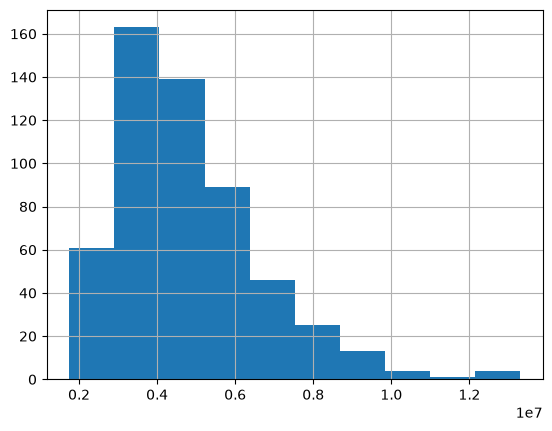

In [66]:
df['price'].hist()


In [67]:
# Outliers
ouliers = df[(df['price']<lower_bound) | (df['price']>upper_bound)]
ouliers

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,semi-furnished
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,semi-furnished
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,unfurnished
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,furnished
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,unfurnished


In [68]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled = scaler.fit_transform(encoded_df[['price','area']])
min_maxScaled_df = encoded_df.copy()
min_maxScaled_df[['price','area']]=scaled
min_maxScaled_df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.000000,0.396564,4,2,3,1,0,0,0,1,2,1,False,False
1,0.909091,0.502405,4,4,4,1,0,0,0,1,3,0,False,False
2,0.909091,0.571134,3,2,2,1,0,1,0,0,2,1,True,False
3,0.906061,0.402062,4,2,2,1,0,1,0,1,3,1,False,False
4,0.836364,0.396564,4,1,2,1,1,1,0,1,2,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,0.006061,0.092784,2,1,1,1,0,1,0,0,2,0,False,True
541,0.001485,0.051546,3,1,1,0,0,0,0,0,0,0,True,False
542,0.000000,0.135395,2,1,1,1,0,0,0,0,0,0,False,True
543,0.000000,0.086598,3,1,1,0,0,0,0,0,0,0,False,False


In [70]:
# Z-Score Standardisation
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
std_scaled = std_scaler.fit_transform(encoded_df[['price','area']])
strandised_df = encoded_df.copy()
strandised_df[['price','area']]=std_scaled
strandised_df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,4.566365,1.046726,4,2,3,1,0,0,0,1,2,1,False,False
1,4.004484,1.757010,4,4,4,1,0,0,0,1,3,0,False,False
2,4.004484,2.218232,3,2,2,1,0,1,0,0,2,1,True,False
3,3.985755,1.083624,4,2,2,1,0,1,0,1,3,1,False,False
4,3.554979,1.046726,4,1,2,1,1,1,0,1,2,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,-1.576868,-0.991879,2,1,1,1,0,1,0,0,2,0,False,True
541,-1.605149,-1.268613,3,1,1,0,0,0,0,0,0,0,True,False
542,-1.614327,-0.705921,2,1,1,1,0,0,0,0,0,0,False,True
543,-1.614327,-1.033389,3,1,1,0,0,0,0,0,0,0,False,False


545